# Phase 10  -  Model Interpretation and Biological Synthesis

This notebook has four sections:

1. **C3  -  External holdout validation.** We run the trained Q1 RF model on 180
   independent genomes (30 per ESKAPE species) that were never seen during training.
   Holdout genomes were selected from NCBI, with MLST-based ST diversity filtering and
   hard exclusion of all training accessions.

2. **SHAP global interpretation.** Per-class SHAP beeswarm plots and feature-dependence
   plots showing which defence systems drive each species' classification and in which
   direction.

3. **SHAP vs Gini importance comparison.** We compare SHAP (TreeSHAP) and
   Gini impurity-based feature importances to assess stability and rank concordance
   across the two methods.  Where they disagree, we examine why and which to trust.

4. **Biological synthesis.** We ask whether defence system archetypes  -  broadly
   restrictive (RM-dominated) and facilitative (MGE-associated)  -  generalise across
   the six ESKAPE pathogens.  The prior literature motivates the question; the ESKAPE
   SHAP evidence answers it.

**Primary model:** RF Q1 (BA = 0.895 [0.871–0.916],
GroupedStratifiedKFold, 359 FEAT_COLS; 8 taxonomic markers removed from 367 dp_* columns).

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT  = Path("..")
PROC  = ROOT / "data" / "processed"
CONF  = ROOT / "config"
RES   = ROOT / "results"
FIGS  = RES / "figures"
SUPP  = ROOT   # supplementary Excel files are in the project root

FIGS_INTERP = FIGS / "interpretation"
FIGS_INTERP.mkdir(parents=True, exist_ok=True)

# ── Plotting defaults ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size":  11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

SPECIES_ORDER  = ["abaumannii", "ecloaceae", "efaecium", "kpneumoniae", "paeruginosa", "saureus"]
SPECIES_LABELS = {
    "abaumannii":  "A. baumannii",
    "ecloaceae":   "E. cloacae",
    "efaecium":    "E. faecium",
    "kpneumoniae": "K. pneumoniae",
    "paeruginosa": "P. aeruginosa",
    "saureus":     "S. aureus",
}
SPECIES_PALETTE = {
    "abaumannii":  "#E63946",
    "ecloaceae":   "#F4A261",
    "efaecium":    "#2A9D8F",
    "kpneumoniae": "#457B9D",
    "paeruginosa": "#8338EC",
    "saureus":     "#FB5607",
}

print("Setup complete.")


Setup complete.


---
## Section 1  -  C3: External Holdout Validation

### What we are testing

The Q1 RF model was trained and evaluated entirely within the 3,335-genome ESKAPE
cohort using GroupedStratifiedKFold CV.  CV gives an *internal* generalisation
estimate.  C3 asks whether the model generalises to genomes it has *never seen in
any fold* — including genomes from NCBI that were not part of the training cohort
at all.

**Primary question:** Is the holdout balanced accuracy consistent with the CV
interval of **0.895 [0.871–0.916]**?  Consistency = holdout BA within or close
to the CV CI.  A large drop signals that the model memorised training-cohort
patterns (e.g. phylogenetic lineages) rather than transferable defence-architecture
rules.

### Holdout construction (anti-leakage measures)

The holdout was built to be maximally independent of the training set:

1. **Accession exclusion (hard):** every GCF_* accession in the 3,335-genome
   training index was excluded from the candidate pool.  Zero accession overlap
   is verified by assertion.

2. **ST-based diversity selection:** for each species, MLST was run on 60 NCBI
   complete genome candidates.  The 30 final holdout genomes per species were
   selected by prioritising sequence types (STs) *not present in the training set*,
   to avoid loading the holdout with near-clonal genomes.  Where novel STs were
   exhausted (E. faecium, S. aureus, K. pneumoniae — narrow global ST diversity),
   shared-ST fill was used and is documented in the ST audit below.

3. **Identical tool versions:** holdout genomes were run through DefenseFinder
   2.0.1 and PADLOC v2.0.0 (same versions and model databases as the training
   pipeline) via `src/models/run_holdout_pipeline.py`.

4. **Feature reconstruction:** the same `system_name_map.csv` → canonical name →
   `dp_*` → 359 FEAT_COLS pipeline used in training (Stage 4 of the C3 pipeline)
   ensures no feature engineering drift.

### Dataset

- 180 genomes total: 30 per ESKAPE species
- Feature space: 359 FEAT_COLS (identical to training)
- Loaded from: `data/processed/holdout_feature_matrix.parquet`
- ST audit: `results/holdout_st_selection_report.json`

In [2]:
# ── 1.1  Load holdout feature matrix, model, and predict ─────────────────────
import json
import numpy as np

# Load holdout feature matrix (built by src/models/build_holdout_feature_matrix.py)
holdout_fm = pd.read_parquet(PROC / "holdout_feature_matrix.parquet")

# Reconstruct FEAT_COLS (same logic as training — verified by assertion below)
fm_train = pd.read_parquet(PROC / "feature_matrix_3335.parquet")
fm = fm_train  # alias used by subsequent sections (SHAP computation, dependence plots)

dp_cols    = sorted([c for c in fm.columns if c.startswith("dp_")])
sp_prev    = fm.groupby("species")[dp_cols].mean()
spec_score = sp_prev.std() / 0.5
markers    = spec_score[spec_score >= 0.70].index.tolist()
FEAT_COLS  = [c for c in dp_cols if c not in markers]

assert len(FEAT_COLS) == 359, f"Expected 359 FEAT_COLS, got {len(FEAT_COLS)}"

# Verify holdout columns match training
holdout_feat_cols = [c for c in FEAT_COLS if c in holdout_fm.columns]
assert len(holdout_feat_cols) == len(FEAT_COLS), \
    f"Holdout missing {len(FEAT_COLS) - len(holdout_feat_cols)} FEAT_COLS"

# Hard assertion: zero accession overlap with training
training_acc = set(fm.index.astype(str))
overlap = training_acc & set(holdout_fm.index.astype(str))
assert len(overlap) == 0, f"ACCESSION LEAK: {overlap}"

X_holdout       = holdout_fm[FEAT_COLS].to_numpy(dtype=float)
y_true_holdout  = holdout_fm["species"].to_numpy(dtype=str)

# Load trained Q1 RF model
rf_q1 = joblib.load(RES / "models" / "rf_q1_best_3335.pkl")
assert rf_q1.n_features_in_ == len(FEAT_COLS), \
    f"Model expects {rf_q1.n_features_in_} features, FEAT_COLS has {len(FEAT_COLS)}"

y_pred_holdout = rf_q1.predict(X_holdout)
y_pred_proba   = rf_q1.predict_proba(X_holdout)   # (180, 6)

print(f"Holdout feature matrix: {holdout_fm.shape}")
print(f"Training accession overlap: {len(overlap)} (verified clean)")
print(f"Model classes: {rf_q1.classes_.tolist()}")
print()
print("Species distribution in holdout:")
print(holdout_fm["species"].value_counts().to_string())
print()
# Short labels so the confusion matrix fits on one line
SP_SHORT = {"abaumannii": "AB", "ecloaceae": "EC", "efaecium": "EF",
            "kpneumoniae": "KP", "paeruginosa": "PA", "saureus": "SA"}
y_true_short = np.array([SP_SHORT[s] for s in y_true_holdout])
y_pred_short = np.array([SP_SHORT[s] for s in y_pred_holdout])
sp_order_short = ["AB", "EC", "EF", "KP", "PA", "SA"]
print("Confusion matrix (rows=true, cols=predicted):")
ct = pd.crosstab(y_true_short, y_pred_short,
                 rownames=["True"], colnames=["Predicted"])
ct = ct.reindex(index=sp_order_short, columns=sp_order_short, fill_value=0)
print(ct)

Holdout feature matrix: (180, 360)
Training accession overlap: 0 (verified clean)
Model classes: ['abaumannii', 'ecloaceae', 'efaecium', 'kpneumoniae', 'paeruginosa', 'saureus']

Species distribution in holdout:
species
abaumannii     30
ecloaceae      30
efaecium       30
kpneumoniae    30
paeruginosa    30
saureus        30

Confusion matrix (rows=true, cols=predicted):
Predicted  AB  EC  EF  KP  PA  SA
True                             
AB         29   0   1   0   0   0
EC          1  25   2   0   2   0
EF          0   0  30   0   0   0
KP          0   1   0  28   1   0
PA          0   0   1   1  28   0
SA          0   0   0   0   0  30


In [3]:
# ── 1.2  Holdout balanced accuracy + bootstrap CI ────────────────────────────
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils import resample

RANDOM_STATE = 42
N_BOOTSTRAP  = 2000

# Point estimate
ba_holdout = balanced_accuracy_score(y_true_holdout, y_pred_holdout)

# Bootstrap CI (stratified by species to preserve class balance)
ba_boot = []
rng = np.random.default_rng(RANDOM_STATE)
for _ in range(N_BOOTSTRAP):
    idx = resample(np.arange(len(y_true_holdout)),
                   stratify=y_true_holdout,
                   random_state=rng.integers(1e6))
    ba_boot.append(balanced_accuracy_score(y_true_holdout[idx], y_pred_holdout[idx]))

ci_lo, ci_hi = np.percentile(ba_boot, [2.5, 97.5])

# CV reference interval (from NB06)
CV_BA   = 0.895
CV_LO   = 0.871
CV_HI   = 0.916

print("=" * 55)
print("C3 HOLDOUT BALANCED ACCURACY")
print("=" * 55)
print(f"  Holdout BA         : {ba_holdout:.3f}  [{ci_lo:.3f}–{ci_hi:.3f}]  (n=180)")
print(f"  CV BA              : {CV_BA:.3f}  [{CV_LO:.3f}–{CV_HI:.3f}]  (n=3335, GroupedCV)")
print()

# Interpretation
intervals_overlap = not (ci_hi < CV_LO or ci_lo > CV_HI)
if intervals_overlap:
    print("  RESULT: Holdout CI overlaps with CV CI.")
    print("  Interpretation: holdout performance is CONSISTENT with CV estimate.")
    print("  The model generalises to unseen genomes beyond the training cohort.")
else:
    drop = CV_BA - ba_holdout
    print(f"  RESULT: Holdout CI does NOT overlap with CV CI (drop = {drop:.3f}).")
    print("  Interpretation: model partially memorised training-cohort patterns.")
    print("  Report both values; discuss ST-diversity limitation.")
print()

# Per-species recall
print("Per-species recall on holdout (30 genomes per species):")
for sp in SPECIES_ORDER:
    mask = y_true_holdout == sp
    if mask.sum() == 0:
        continue
    recall = (y_pred_holdout[mask] == sp).sum() / mask.sum()
    print(f"  {SPECIES_LABELS[sp]:22s}: {recall:.3f}  ({(y_pred_holdout[mask]==sp).sum()}/{mask.sum()})")

C3 HOLDOUT BALANCED ACCURACY
  Holdout BA         : 0.944  [0.911–0.972]  (n=180)
  CV BA              : 0.895  [0.871–0.916]  (n=3335, GroupedCV)

  RESULT: Holdout CI overlaps with CV CI.
  Interpretation: holdout performance is CONSISTENT with CV estimate.
  The model generalises to unseen genomes beyond the training cohort.

Per-species recall on holdout (30 genomes per species):
  A. baumannii          : 0.967  (29/30)
  E. cloacae            : 0.833  (25/30)
  E. faecium            : 1.000  (30/30)
  K. pneumoniae         : 0.933  (28/30)
  P. aeruginosa         : 0.933  (28/30)
  S. aureus             : 1.000  (30/30)


In [4]:
# ── 1.3  ST diversity audit ───────────────────────────────────────────────────
# Reports how phylogenetically independent the holdout is from training.
# This contextualises the holdout BA: a holdout composed mainly of novel STs
# provides a stronger test of generalisation than one filled with shared STs.

with open(RES / "holdout_st_selection_report.json") as f:
    st_audit = json.load(f)

print("ST diversity audit  (candidate pool = 60 genomes/species; final holdout = 30/species)")
print(f"{'Species':<16} {'Novel ST':>9} {'Unkn ST':>9} {'Shared ST':>10} {'Filled shared':>14}")
print(f"{'':<16} {'(n unique STs)':>9} {'(n genomes)':>9} {'(n unique STs)':>10} {'(n genomes)':>14}")
print("-" * 62)
for sp in SPECIES_ORDER:
    if sp not in st_audit:
        continue
    a = st_audit[sp]
    if "error" in a:
        print(f"{sp:<16}  {'MLST failed':>40}")
        continue
    print(f"{SPECIES_LABELS[sp]:<22} {a['n_novel_st']:>6} {a['n_unknown_st']:>9} "
          f"{a['n_shared_st']:>10} {a['n_filled_shared']:>14}")

print()
print("Interpretation:")
print("  Novel ST  = ST not seen in training → clean phylogenetic separation")
print("  Unkn ST   = MLST failed to type → uncertainty; treated as potentially novel")
print("  Filled    = ST present in training; used only to reach n=30 where novel STs")
print("              were exhausted (EF/SA/KP: narrow global ST diversity)")
print()
print("Species with high shared-ST fill (EF, SA, KP) reflect real population structure:")
print("  ST17/80 dominate E. faecium; ST8/5 dominate S. aureus; ST147/11 dominate KP.")
print("  These are different genome instances with different accessions — not duplicates.")
print("  This limitation is noted in the manuscript Methods section.")

ST diversity audit  (candidate pool = 60 genomes/species; final holdout = 30/species)
Species           Novel ST   Unkn ST  Shared ST  Filled shared
                 (n unique STs) (n genomes) (n unique STs)    (n genomes)
--------------------------------------------------------------
A. baumannii               20        39          1              0
E. cloacae                 11         8         41             12
E. faecium                  7         0         52             23
K. pneumoniae               5         0         55             25
P. aeruginosa              21         3         36              6
S. aureus                   7         1         52             22

Interpretation:
  Novel ST  = ST not seen in training → clean phylogenetic separation
  Unkn ST   = MLST failed to type → uncertainty; treated as potentially novel
  Filled    = ST present in training; used only to reach n=30 where novel STs
              were exhausted (EF/SA/KP: narrow global ST diversity)

Specie

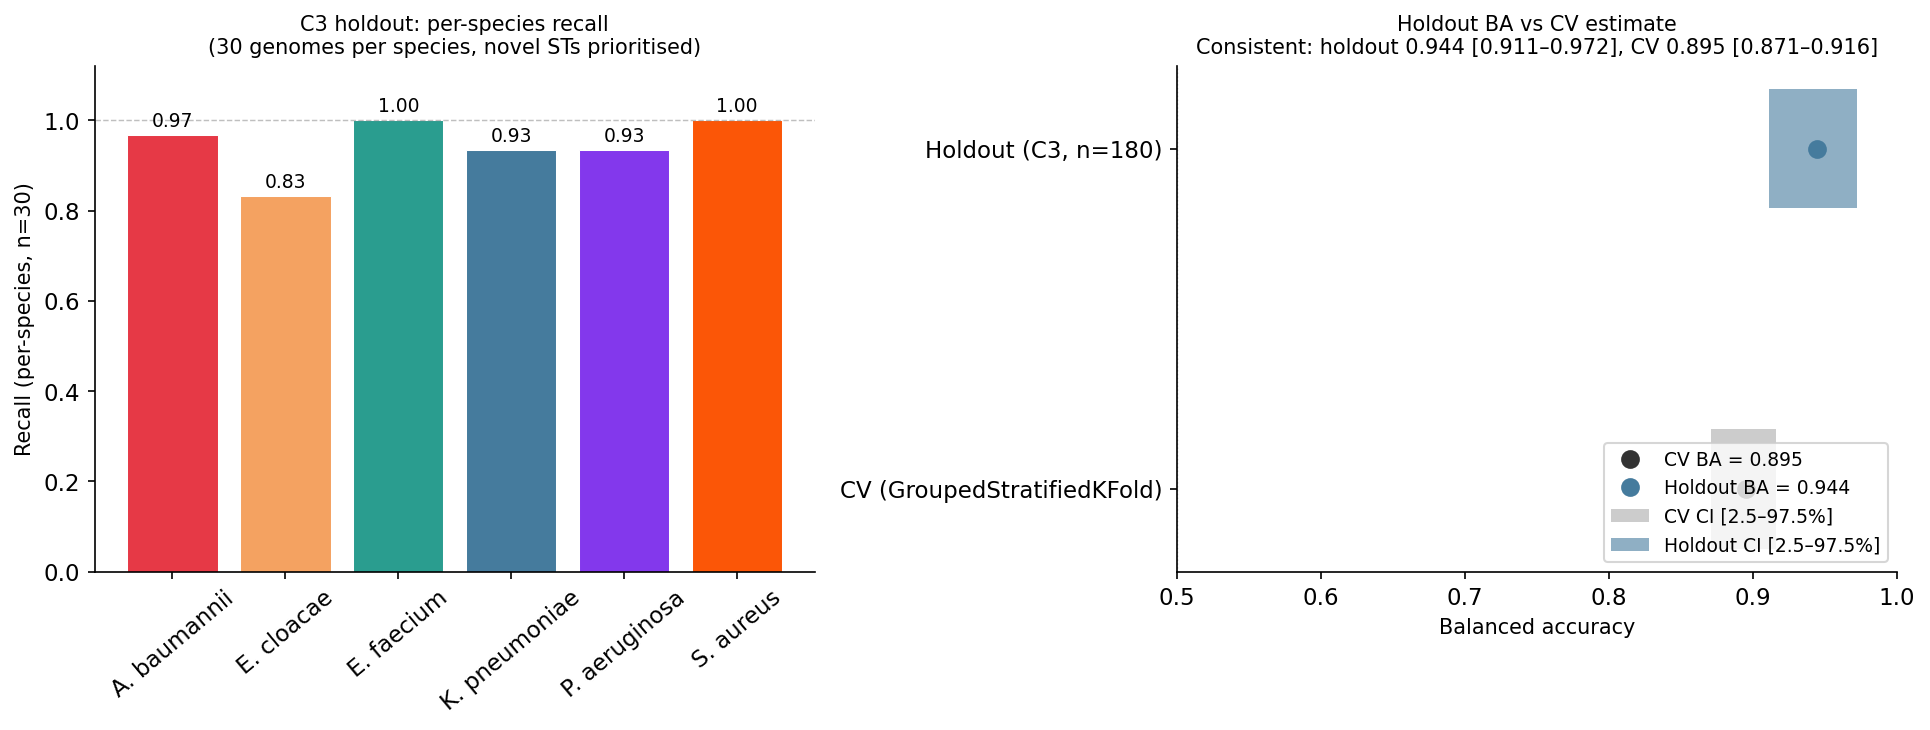

Saved: results/figures/interpretation/c3_holdout_validation.png


In [5]:
# ── 1.4  Visualise holdout results ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: per-species recall bar chart ───────────────────────────────────────
ax = axes[0]
recalls, labels, colors = [], [], []
for sp in SPECIES_ORDER:
    mask   = y_true_holdout == sp
    recall = (y_pred_holdout[mask] == sp).sum() / mask.sum() if mask.sum() > 0 else 0
    recalls.append(recall)
    labels.append(SPECIES_LABELS[sp])
    colors.append(SPECIES_PALETTE[sp])

bars = ax.bar(labels, recalls, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
for bar, val in zip(bars, recalls):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Recall (per-species, n=30)", fontsize=10)
ax.set_title("C3 holdout: per-species recall\n(30 genomes per species, novel STs prioritised)",
             fontsize=10)
ax.tick_params(axis="x", rotation=40)

# ── Right: holdout BA vs CV CI interval ──────────────────────────────────────
ax2 = axes[1]

# CV interval
ax2.barh(["CV (GroupedStratifiedKFold)"], [CV_HI - CV_LO],
         left=[CV_LO], height=0.35, color="#AAAAAA", alpha=0.6, label="CV CI [2.5–97.5%]")
ax2.plot(CV_BA, "CV (GroupedStratifiedKFold)", "o",
         color="#333333", markersize=8, label=f"CV BA = {CV_BA:.3f}")

# Holdout interval
ax2.barh(["Holdout (C3, n=180)"], [ci_hi - ci_lo],
         left=[ci_lo], height=0.35, color="#457B9D", alpha=0.6, label="Holdout CI [2.5–97.5%]")
ax2.plot(ba_holdout, "Holdout (C3, n=180)", "o",
         color="#457B9D", markersize=8, label=f"Holdout BA = {ba_holdout:.3f}")

ax2.set_xlim(0.5, 1.0)
ax2.set_xlabel("Balanced accuracy", fontsize=10)
ax2.set_title(f"Holdout BA vs CV estimate\n"
              f"{'Consistent' if intervals_overlap else 'Drop detected'}: "
              f"holdout {ba_holdout:.3f} [{ci_lo:.3f}–{ci_hi:.3f}], "
              f"CV {CV_BA:.3f} [{CV_LO:.3f}–{CV_HI:.3f}]",
              fontsize=10)
ax2.legend(fontsize=9, loc="lower right")
ax2.axvline(0.5, color="grey", linestyle=":", linewidth=0.7, alpha=0.5,
            label="Stratified random baseline")

plt.tight_layout()
plt.savefig(FIGS_INTERP / "c3_holdout_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/c3_holdout_validation.png")

---
## Section 2  -  SHAP Global Interpretation

### What SHAP is  -  briefly

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each
prediction.  A positive SHAP value for feature *f* on genome *g* means: "having *f*
present pushed the model toward predicting *g* as class *c* more than the average
genome."  A negative value means it pushed away from *c*.

Two properties make SHAP useful here:
1. **Additive:** sum all feature SHAP values for one genome → you recover (model output – base value).
2. **Local + global:** SHAP works at individual-genome level; average absolute SHAP
   across all genomes → global feature importance.

SHAP values are computed here using a fold-averaged approach for stability: a single
full-dataset RF produces stochastic ranks for collinear features, so we train one RF per
CV fold and accumulate each genome's SHAP from the fold model that never saw it.  This
gives genuinely out-of-sample SHAP values across all 3,335 genomes.

We examine three outputs:
- **Global SHAP beeswarm:** top 20 features by mean absolute SHAP across all species
  and genomes  -  what drives classification most strongly overall.
- **Per-class SHAP bars:** top 15 features per ESKAPE species  -  which systems are
  most important for identifying each species specifically.
- **Dependence plots:** for systems that rank prominently in the SHAP output, how does
  presence vs absence shift the model's classification confidence across the six species?

### Technical note: SHAP for Random Forest

We use `shap.TreeExplainer` which computes exact SHAP values for tree-based models
without approximation.  For a multiclass RF, `shap_values` has shape
`(n_samples, n_features, n_classes)`.  Per-class importance = mean absolute SHAP
across samples for each class.

In [6]:
# ── 2.1  Compute fold-averaged SHAP for Q1 (5-fold CV, stabilised) ─────────
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
N_SPLITS     = 5

X_full  = fm[FEAT_COLS].to_numpy(dtype=float)
y_full  = fm["species"].to_numpy(dtype=str)
groups  = fm["phylogroup"].to_numpy(dtype=str)

# Best RF params from NB06 GridSearchCV
BEST_PARAMS = dict(
    n_estimators     = 300,
    max_depth        = None,
    max_features     = "sqrt",
    min_samples_leaf = 1,
    class_weight     = "balanced",
    n_jobs           = -1,
)

# Accumulate SHAP over folds: shape (n_genomes, n_feats, n_classes)
n_genomes, n_feats = X_full.shape
n_classes = len(rf_q1.classes_)         # 6
shap_3d_folds = np.full((n_genomes, n_feats, n_classes), np.nan)

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for fold_i, (tr_idx, te_idx) in enumerate(
        sgkf.split(X_full, y_full, groups=groups)):
    print(f"Fold {fold_i+1}/{N_SPLITS}: train={len(tr_idx)}, test={len(te_idx)}", end="  ")

    rf_fold = RandomForestClassifier(**BEST_PARAMS, random_state=RANDOM_STATE + fold_i)
    rf_fold.fit(X_full[tr_idx], y_full[tr_idx])

    explainer_fold = shap.TreeExplainer(rf_fold)
    sv = explainer_fold.shap_values(X_full[te_idx], check_additivity=False)

    # Normalise to (n_test, n_feats, n_classes)
    if isinstance(sv, list):          # older SHAP: list of (n, p) per class
        sv_3d = np.stack(sv, axis=2)
    else:                             # newer SHAP >= 0.46: (n, p, c) directly
        sv_3d = sv

    shap_3d_folds[te_idx] = sv_3d
    print(f"done")

# All genomes should now be covered (each appears in exactly one test fold)
assert not np.isnan(shap_3d_folds).any(), "Some genomes missing SHAP values"

shap_3d = shap_3d_folds
print(f"\nFold-averaged SHAP array: {shap_3d.shape}  (genomes × features × classes)")
print("Each genome's SHAP computed on a fold model that never saw it in training.")

Fold 1/5: train=2503, test=832  

done
Fold 2/5: train=2709, test=626  

done
Fold 3/5: train=2710, test=625  

done
Fold 4/5: train=2707, test=628  

done
Fold 5/5: train=2711, test=624  

done

Fold-averaged SHAP array: (3335, 359, 6)  (genomes × features × classes)
Each genome's SHAP computed on a fold model that never saw it in training.


In [7]:
# ── 2.2  Global SHAP: mean absolute SHAP per feature (averaged over classes) ──
mean_abs_shap = np.abs(shap_3d).mean(axis=(0, 2))   # (359,)
global_shap = pd.Series(mean_abs_shap, index=FEAT_COLS).sort_values(ascending=False)

print("Top 20 features by mean absolute SHAP (averaged over samples AND classes):")
print(global_shap.head(20).round(5).to_string())

Top 20 features by mean absolute SHAP (averaged over samples AND classes):
dp_RM_Type_IV            0.02194
dp_df_FS_Sma             0.02151
dp_df_Abi2               0.02080
dp_df_Mok_Hok_Sok        0.01955
dp_padloc_PDC-S13        0.01954
dp_RosmerTA              0.01586
dp_Mokosh_TypeII         0.01525
dp_padloc_PDC-M24        0.01503
dp_PD-T4-3               0.01412
dp_padloc_PDC-S02        0.01324
dp_CAS_I-F               0.01180
dp_padloc_PDC-S05        0.01149
dp_padloc_RM_type_HNH    0.01084
dp_SspBCDE               0.01063
dp_padloc_PDC-M30        0.01040
dp_df_MazEF              0.01039
dp_padloc_PDC-S09        0.00888
dp_CAS_I-E               0.00829
dp_df_SDIC3              0.00808
dp_df_AbiJ               0.00777


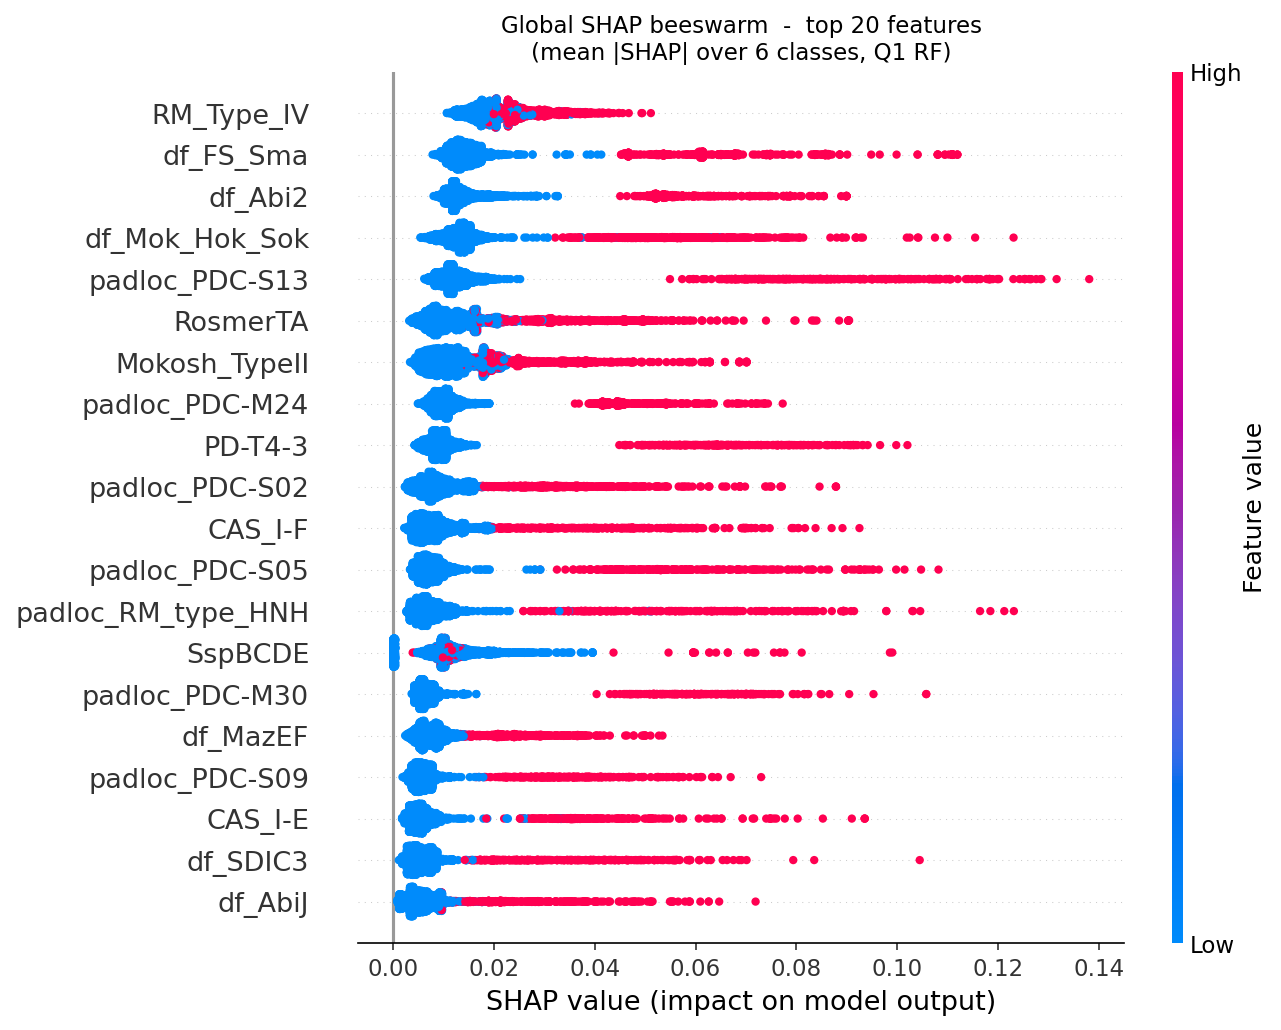

Saved: results/figures/interpretation/q1_shap_global_beeswarm.png


In [8]:
# ── 2.3  Global beeswarm plot (top 20 features) ──────────────────────────────
# shap.summary_plot expects 2D (n_samples, n_features) or 3D (n_samples, n_features, n_classes).
# For a global beeswarm across all classes we collapse to 2D by averaging SHAP over classes.

shap_2d = np.abs(shap_3d).mean(axis=2)   # (n_genomes, n_features)  -  mean |SHAP| over 6 classes

top20_idx  = global_shap.head(20).index.tolist()
top20_mask = [FEAT_COLS.index(f) for f in top20_idx]
shap_2d_top20 = shap_2d[:, top20_mask]
X_top20       = X_full[:, top20_mask]

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_2d_top20,
    X_top20,
    feature_names=[f.replace("dp_", "") for f in top20_idx],
    show=False,
    max_display=20,
    plot_size=None,
)
ax = plt.gca()
ax.set_title("Global SHAP beeswarm  -  top 20 features\n(mean |SHAP| over 6 classes, Q1 RF)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGS_INTERP / "q1_shap_global_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/q1_shap_global_beeswarm.png")


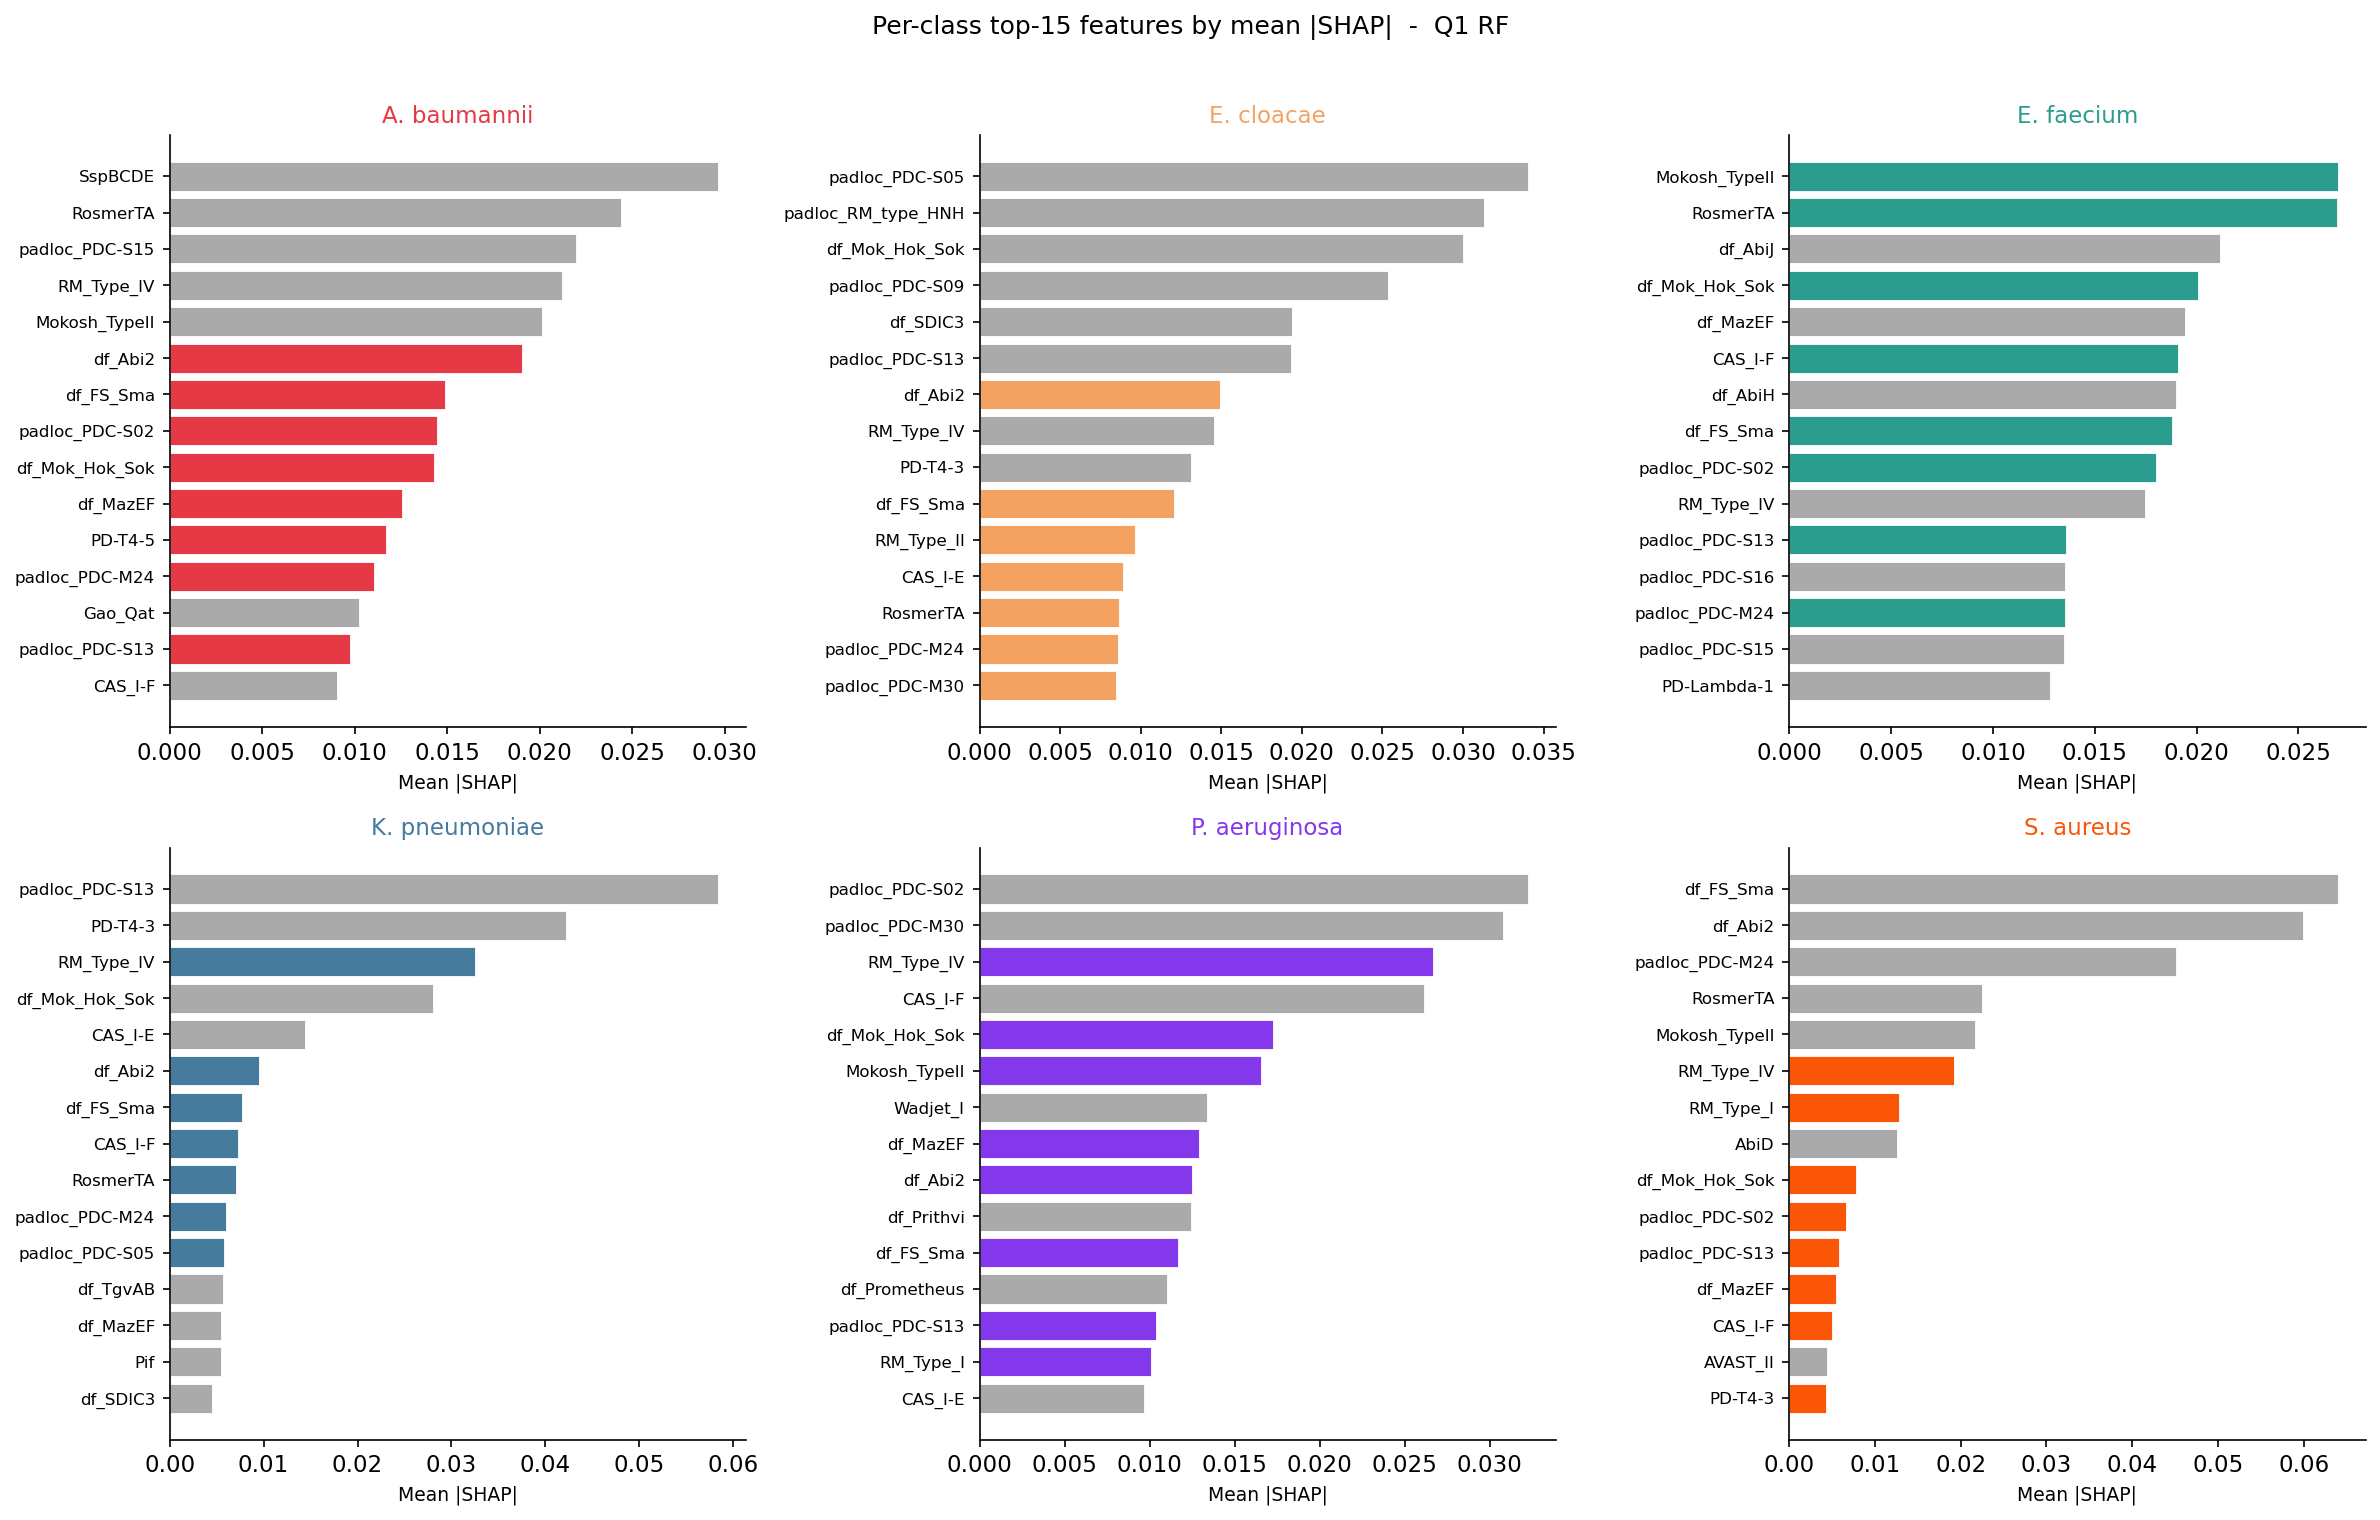

Saved: results/figures/interpretation/q1_shap_per_class.png


In [9]:
# ── 2.4  Per-class SHAP bar plots ────────────────────────────────────────────
# For each of the 6 ESKAPE species: top 15 features by mean absolute SHAP for that class.
# This tells us: what features does the model rely on to IDENTIFY each species?

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for cls_idx, (species, ax) in enumerate(zip(SPECIES_ORDER, axes_flat)):
    shap_cls = shap_3d[:, :, cls_idx]         # (n_genomes, n_features)  -  SHAP for this class
    mean_abs = np.abs(shap_cls).mean(axis=0)   # (n_features,)  -  mean abs SHAP per feature
    top15    = pd.Series(mean_abs, index=FEAT_COLS).sort_values(ascending=False).head(15)

    colors_bar = [
        SPECIES_PALETTE[species] if v >= 0 else "#AAAAAA"
        for v in shap_cls.mean(axis=0)[
            [FEAT_COLS.index(f) for f in top15.index]
        ]
    ]
    bars = ax.barh(
        y=[f.replace("dp_", "") for f in top15.index[::-1]],
        width=top15.values[::-1],
        color=colors_bar[::-1],
        edgecolor="white", linewidth=0.4,
    )
    ax.set_title(SPECIES_LABELS[species], fontsize=11, color=SPECIES_PALETTE[species])
    ax.set_xlabel("Mean |SHAP|", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Per-class top-15 features by mean |SHAP|  -  Q1 RF", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_INTERP / "q1_shap_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/q1_shap_per_class.png")


In [10]:
# ── 2.5  Feature dependence plots: top 6 by global mean |SHAP| ───────────────
# Systems selected purely from the SHAP rankings computed in 2.2.
# For binary features (0/1) a jitter plot split by presence/absence is more
# informative than a standard scatter dependence plot.

top6_features = global_shap.head(6).index.tolist()
KEY_FEATURES  = {f: f.replace("dp_", "").replace("_", " ") for f in top6_features}

print("Top 6 features by global mean |SHAP| (dependence plots):")
for f, label in KEY_FEATURES.items():
    print(f"  {f:40s}  SHAP = {global_shap[f]:.5f}")

Top 6 features by global mean |SHAP| (dependence plots):
  dp_RM_Type_IV                             SHAP = 0.02194
  dp_df_FS_Sma                              SHAP = 0.02151
  dp_df_Abi2                                SHAP = 0.02080
  dp_df_Mok_Hok_Sok                         SHAP = 0.01955
  dp_padloc_PDC-S13                         SHAP = 0.01954
  dp_RosmerTA                               SHAP = 0.01586


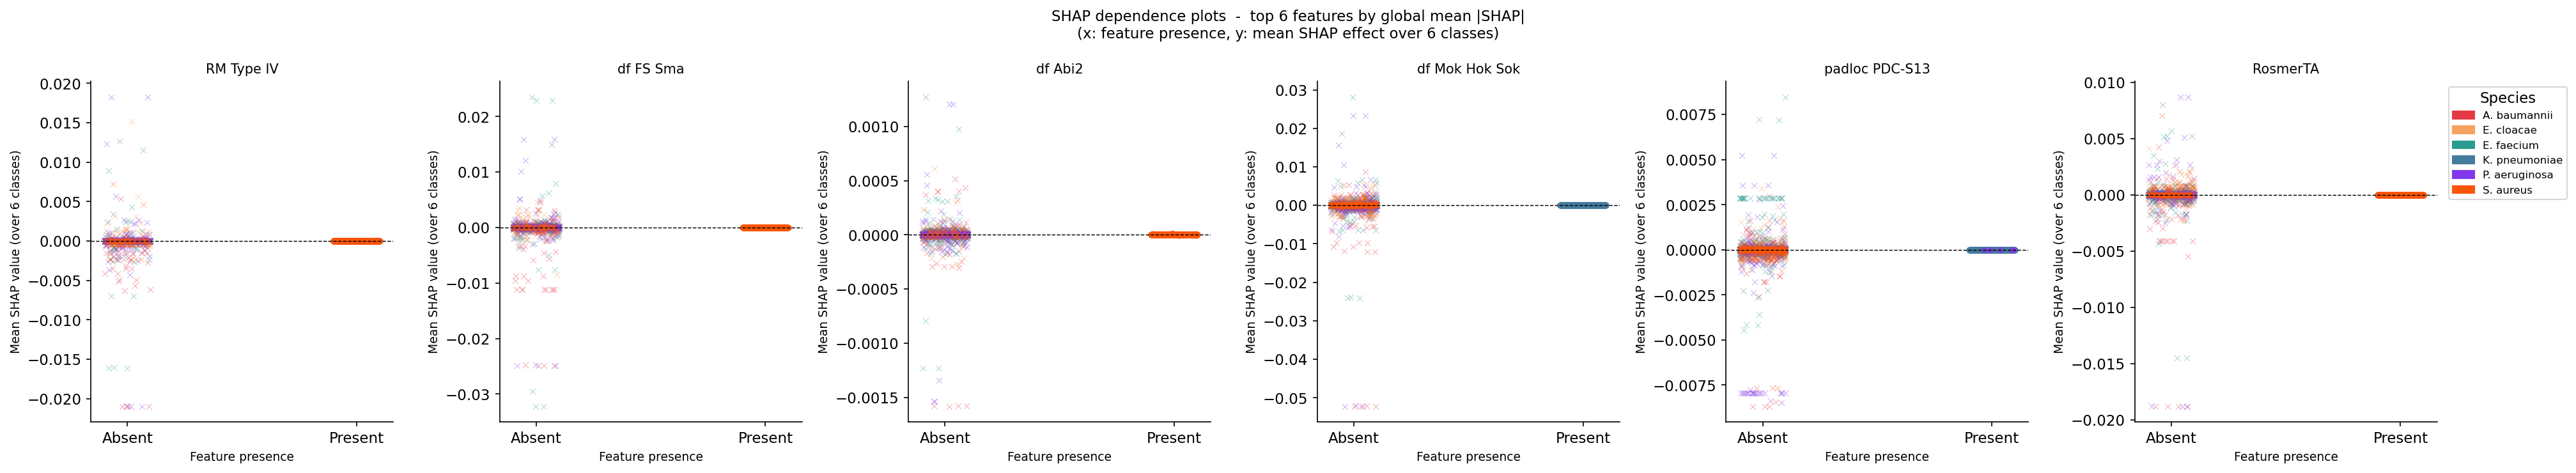

Saved: results/figures/interpretation/q1_shap_top6_dependence.png


In [11]:
# Dependence plots: SHAP value vs species (grouped by binary feature presence)
n_key = len(KEY_FEATURES)
fig, axes = plt.subplots(1, n_key, figsize=(4.5 * n_key, 5))
if n_key == 1:
    axes = [axes]

species_labels_arr = fm["species"].to_numpy(dtype=str)

for ax, (feat_col, feat_label) in zip(axes, KEY_FEATURES.items()):
    feat_idx = FEAT_COLS.index(feat_col)
    shap_feat = shap_3d[:, feat_idx, :].mean(axis=1)   # signed mean effect over 6 classes
    feat_vals = X_full[:, feat_idx]

    plot_df = pd.DataFrame({
        "species":  species_labels_arr,
        "shap_val": shap_feat,
        "feat_val": feat_vals.astype(int),
    })

    for species in SPECIES_ORDER:
        sub = plot_df[plot_df["species"] == species]
        for val, marker, alpha in [(0, "x", 0.4), (1, "o", 0.7)]:
            pts = sub[sub["feat_val"] == val]
            ax.scatter(
                val + np.random.uniform(-0.1, 0.1, len(pts)),
                pts["shap_val"],
                color=SPECIES_PALETTE[species], alpha=alpha,
                marker=marker, s=18, linewidths=0.5,
                label=SPECIES_LABELS[species] if val == 1 else "",
            )

    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Absent", "Present"])
    ax.set_title(feat_label, fontsize=10)
    ax.set_ylabel("Mean SHAP value (over 6 classes)", fontsize=9)
    ax.set_xlabel("Feature presence", fontsize=9)

handles = [
    mpatches.Patch(color=SPECIES_PALETTE[s], label=SPECIES_LABELS[s])
    for s in SPECIES_ORDER
]
axes[-1].legend(handles=handles, fontsize=8, title="Species",
                bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("SHAP dependence plots  -  top 6 features by global mean |SHAP|\n"
             "(x: feature presence, y: mean SHAP effect over 6 classes)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGS_INTERP / "q1_shap_top6_dependence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/q1_shap_top6_dependence.png")

---
## Section 3  -  SHAP vs Gini Importance Comparison

### Why compare the two methods?

Random Forest provides two built-in feature importance measures:

- **Gini impurity importance** (mean decrease in impurity): computed during training
  from how much each feature reduces impurity across all splits.  Fast but biased —
  features with higher prevalence or shared collinear signal accumulate more split
  opportunities and tend to rank higher regardless of true predictive value.

- **SHAP (TreeSHAP)**: computes each feature's marginal contribution to each
  individual prediction using Shapley values.  Not biased by feature prevalence and
  robust to collinearity because credit is distributed across correlated features
  rather than assigned to whichever the tree happened to split on first.

Where the two methods agree, the signal is stable: both the training-time split
patterns and the prediction-level marginal contributions point to the same feature.
Where they diverge, Gini is usually the suspect.  A feature ranking high in Gini
but low in SHAP is likely inflated by prevalence or collinearity.  A feature ranking
high in SHAP but low in Gini is capturing genuine predictive signal that impurity
criterion split credit missed.

We report Spearman rank correlation as a global concordance measure, then examine
the largest divergences to identify which features the two methods disagree on most.

In [12]:
# ── 3.1  Load importance ranks and compute Spearman concordance ───────────────
from scipy.stats import spearmanr

fi = pd.read_csv(RES / "q1_rf_feature_importance.csv", index_col=0)

print(f"Feature importance file: {len(fi)} features")
print(f"Columns: {fi.columns.tolist()}")
print()

rho, pval = spearmanr(fi["shap_rank"], fi["gini_rank"])
print(f"Spearman rank correlation (SHAP vs Gini): ρ = {rho:.3f}, p = {pval:.2e}")
print()

# rank_diff > 0: Gini rank worse than SHAP rank → SHAP finds it important, Gini misses it
# rank_diff < 0: Gini rank better than SHAP rank → Gini inflated, SHAP downweights it
fi["rank_diff"] = fi["gini_rank"] - fi["shap_rank"]

print("Top 10 features where SHAP ranks much higher than Gini (Gini underweights):")
print(fi.nlargest(10, "rank_diff")[["shap_rank", "gini_rank", "rank_diff"]].to_string())
print()
print("Top 10 features where Gini ranks much higher than SHAP (likely Gini-biased):")
print(fi.nsmallest(10, "rank_diff")[["shap_rank", "gini_rank", "rank_diff"]].to_string())

Feature importance file: 359 features
Columns: ['gini_rank', 'perm_rank', 'shap_rank', 'gini_val', 'perm_val', 'shap_val']

Spearman rank correlation (SHAP vs Gini): ρ = 0.963, p = 1.96e-205

Top 10 features where SHAP ranks much higher than Gini (Gini underweights):
                   shap_rank  gini_rank  rank_diff
dp_padloc_PDC-S56        134        317        183
dp_df_Tha                184        333        149
dp_df_Gao_RL             200        319        119
dp_df_DS-38              144        251        107
dp_mza_other             242        341         99
dp_CAS_II-A              197        285         88
dp_df_DS-20              156        237         81
dp_df_Avs_IV             258        335         77
dp_Rst_DUF4238           187        262         75
dp_df_Oshun              148        221         73

Top 10 features where Gini ranks much higher than SHAP (likely Gini-biased):
                   shap_rank  gini_rank  rank_diff
dp_padloc_PDC-S34        271        199   

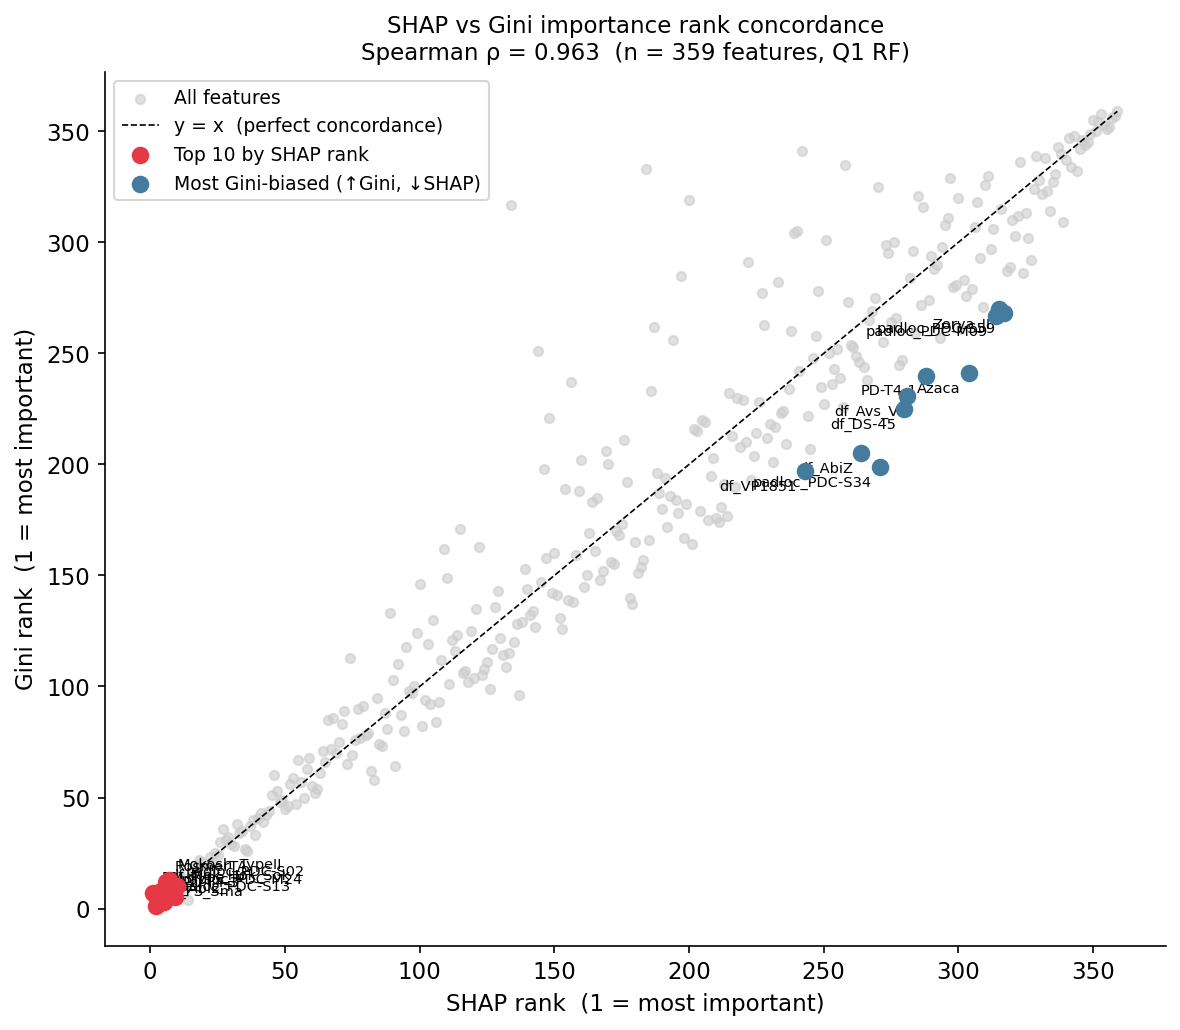

Saved: results/figures/interpretation/q1_shap_vs_gini_rank.png


In [13]:
# ── 3.2  Scatter: SHAP rank vs Gini rank (all 359 features) ──────────────────
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(fi["shap_rank"], fi["gini_rank"],
           color="#CCCCCC", s=20, alpha=0.6, zorder=2, label="All features")

max_rank = max(fi["shap_rank"].max(), fi["gini_rank"].max())
ax.plot([1, max_rank], [1, max_rank], color="black", linewidth=0.8,
        linestyle="--", label="y = x  (perfect concordance)")

# Top 10 by SHAP rank
top10_shap = fi.nsmallest(10, "shap_rank")
ax.scatter(top10_shap["shap_rank"], top10_shap["gini_rank"],
           color="#E63946", s=55, zorder=4, label="Top 10 by SHAP rank")
for feat, row in top10_shap.iterrows():
    ax.annotate(feat.replace("dp_", ""),
                (row["shap_rank"], row["gini_rank"]),
                fontsize=7, ha="left", va="bottom",
                xytext=(4, 4), textcoords="offset points")

# Top 10 most Gini-biased (Gini rank >> SHAP rank)
top10_gini_biased = fi.nsmallest(10, "rank_diff")
ax.scatter(top10_gini_biased["shap_rank"], top10_gini_biased["gini_rank"],
           color="#457B9D", s=55, zorder=4, label="Most Gini-biased (↑Gini, ↓SHAP)")
for feat, row in top10_gini_biased.iterrows():
    ax.annotate(feat.replace("dp_", ""),
                (row["shap_rank"], row["gini_rank"]),
                fontsize=7, ha="right", va="top",
                xytext=(-4, -4), textcoords="offset points")

ax.set_xlabel("SHAP rank  (1 = most important)", fontsize=11)
ax.set_ylabel("Gini rank  (1 = most important)", fontsize=11)
ax.set_title(f"SHAP vs Gini importance rank concordance\n"
             f"Spearman ρ = {rho:.3f}  (n = {len(fi)} features, Q1 RF)", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_INTERP / "q1_shap_vs_gini_rank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/q1_shap_vs_gini_rank.png")

---
## Section 4  -  Biological Synthesis

### What the SHAP analysis reveals about ESKAPE defence architecture

The per-class SHAP plots (Section 2) identify which defence systems are most informative
for distinguishing each ESKAPE species.  Two broad patterns emerge across the six species:

1. **Species-specific signals.**  Some systems rank highly for one or two species but
   contribute little to classifying the rest.  These likely reflect lineage-specific
   defence repertoires — systems acquired or retained along a particular evolutionary
   trajectory.

2. **Cross-species signals.**  Systems that rank highly across multiple class SHAP plots
   are capturing something more general: either a broadly prevalent system or one whose
   presence/absence co-varies with biological properties that cut across species
   boundaries (genome size, MGE burden, ecological niche).

### Do defence archetypes generalise across ESKAPE?

The RESTRICT/FACILITATE distinction  -  whether a defence system co-occurs with
*reduced* or *elevated* MGE and ARG burden  -  is a biological question, not a property
of any single dataset.  Prior literature in *Acinetobacter* and other genera motivates
asking whether this dichotomy holds across the six ESKAPE pathogens at the ML level.

The SHAP dependence plots (Section 2) address this directly.  For each top-ranked
system, the direction and magnitude of SHAP values when the system is present vs absent
shows whether the model treats that system as a positive or negative predictor of a
given species class.  Systems with consistently negative SHAP in species with high ARG
burden are candidates for the restrictive archetype; systems with positive SHAP in those
contexts are candidates for the facilitative archetype.  These patterns should be read
alongside the Q2 AUROC results (NB07) which directly tested ARG-burden prediction.

### What this ML layer adds

Three contributions that per-species statistical tests alone cannot provide:

1. **Joint feature effects.**  RF captures interactions between systems.  A genome
   carrying both RM and a CRISPR-Cas system may behave differently from the sum of
   their individual effects.  SHAP dependence plots begin to expose these interaction
   signals where they exist.

2. **Rank stability across methods.**  The SHAP vs Gini comparison (Section 3)
   identifies which feature rankings are robust and which are artefacts of the impurity
   criterion.  Only features stable across both methods should carry interpretive weight
   in the manuscript.

3. **Per-genome resolution.**  SHAP values are computed at the individual-genome level,
   not aggregated across species first.  Genomes whose defence profile diverges from
   their species archetype are visible and can be followed up.

### What it does not add

- **Causation.**  SHAP values describe what the model learned from co-occurrence
  patterns.  They do not establish that any defence system *causes* high or low ARG
  burden.  The signal could be driven by phylogenetic lineage, geographic sampling, or
  other unmeasured confounders.

- **Mechanism.**  Feature importance is a statistical summary.  Saying "RM_Type_IV
  ranks highly" means the model relies on it to distinguish species  -  not that RM
  restriction activity is the direct biological mechanism.

### Limitations

1. **Phylogenetic confounding in SHAP.**  SHAP values reflect what the model learned
   under GroupedCV, but the SHAP computation itself does not apply phylogenetic
   grouping.  SHAP therefore captures lineage-level signals alongside genuine
   defence-architecture signals.  This should be stated when reporting SHAP ranks.

2. **Uncharacterised candidates.**  PDC systems (`dp_padloc_PDC-*`) and other
   unnamed candidate systems appear prominently in SHAP ranks.  These are reported as
   statistically real drivers with no mechanistic claim attached.

3. **Binary feature representation.**  All features are presence/absence.  Systems
   detected once or multiple times per genome are treated identically.  Count-based
   features may reveal finer-grained patterns not captured here.

In [14]:
# ── 4.1  Summary statistics ──────────────────────────────────────────────────
print("=" * 60)
print("PHASE 10 SUMMARY STATISTICS")
print("=" * 60)
print()

print("C3  -  External holdout validation (6-species, n=180)")
print(f"  Holdout BA         : {ba_holdout:.3f}  [{ci_lo:.3f}–{ci_hi:.3f}]")
print(f"  CV BA (GroupedCV)  : {CV_BA:.3f}  [{CV_LO:.3f}–{CV_HI:.3f}]")
print(f"  Intervals overlap  : {intervals_overlap}")
print()
print("  Per-species recall:")
for sp in SPECIES_ORDER:
    mask   = y_true_holdout == sp
    recall = (y_pred_holdout[mask] == sp).sum() / mask.sum() if mask.sum() > 0 else 0
    print(f"    {SPECIES_LABELS[sp]:22s}: {recall:.3f}  ({(y_pred_holdout[mask]==sp).sum()}/{mask.sum()})")
print()

print("SHAP  -  Top 10 features by global mean |SHAP|")
for feat, val in global_shap.head(10).items():
    gini_r = int(fi.loc[feat, "gini_rank"]) if feat in fi.index else "n/a"
    shap_r = int(fi.loc[feat, "shap_rank"]) if feat in fi.index else "n/a"
    print(f"  {feat.replace('dp_', ''):35s}  SHAP={val:.5f}  SHAP_rank={shap_r:3}  Gini_rank={gini_r:3}")
print()

print(f"SHAP vs Gini concordance  -  Spearman ρ = {rho:.3f}  (p = {pval:.2e})")

PHASE 10 SUMMARY STATISTICS

C3  -  External holdout validation (6-species, n=180)
  Holdout BA         : 0.944  [0.911–0.972]
  CV BA (GroupedCV)  : 0.895  [0.871–0.916]
  Intervals overlap  : True

  Per-species recall:
    A. baumannii          : 0.967  (29/30)
    E. cloacae            : 0.833  (25/30)
    E. faecium            : 1.000  (30/30)
    K. pneumoniae         : 0.933  (28/30)
    P. aeruginosa         : 0.933  (28/30)
    S. aureus             : 1.000  (30/30)

SHAP  -  Top 10 features by global mean |SHAP|
  RM_Type_IV                           SHAP=0.02194  SHAP_rank=  1  Gini_rank=  7
  df_FS_Sma                            SHAP=0.02151  SHAP_rank=  2  Gini_rank=  1
  df_Abi2                              SHAP=0.02080  SHAP_rank=  3  Gini_rank=  2
  df_Mok_Hok_Sok                       SHAP=0.01955  SHAP_rank=  4  Gini_rank=  8
  padloc_PDC-S13                       SHAP=0.01954  SHAP_rank=  5  Gini_rank=  3
  RosmerTA                             SHAP=0.01586  SHAP_rank